In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import pickle
from tensorflow.keras.optimizers import Adam

In [3]:
tfidf_matrix= np.load("../data/tfidf_matrix.npy")

with open("../data/tfidf_vectorizer.pkl", "rb") as f:
    tfid_vectorizer= pickle.load(f)

categories_df= pd.read_csv("../data/CategoryLabels.csv")

In [10]:
tfidf_matrix.shape
categories_df.shape
categories_df.head()

,Category
0,HR
1,HR
2,HR
3,HR
4,HR


In [7]:
encoder= LabelEncoder()

In [11]:
categories_transformed= encoder.fit_transform(categories_df["Category"])

In [14]:
with open("../data/Categories_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

In [17]:
print(categories_transformed[:5])
print(encoder.classes_)

[19 19 19 19 19]
['ACCOUNTANT' 'ADVOCATE' 'AGRICULTURE' 'APPAREL' 'ARTS' 'AUTOMOBILE'
 'AVIATION' 'BANKING' 'BPO' 'BUSINESS-DEVELOPMENT' 'CHEF' 'CONSTRUCTION'
 'CONSULTANT' 'DESIGNER' 'DIGITAL-MEDIA' 'ENGINEERING' 'FINANCE' 'FITNESS'
 'HEALTHCARE' 'HR' 'INFORMATION-TECHNOLOGY' 'PUBLIC-RELATIONS' 'SALES'
 'TEACHER']


In [19]:
X= tfidf_matrix.copy()
y= categories_transformed.copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape)
print(X_test.shape)


(1986, 8000)
(497, 8000)


In [27]:
model= Sequential([
    Dense(512, input_dim=8000, activation= 'relu'),
    Dropout(0.5),
    Dense(256, activation= 'relu'),
    Dropout(0.5),
    Dense(24, activation= 'softmax')
])

d:\Github-Repos\AI-Resume-Analyzer\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.compile(optimizer= Adam(learning_rate= 0.001), 
              loss= 'sparse_categorical_crossentropy', 
              metrics= ['accuracy'])

In [29]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │     4,096,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,234,008 (16.15 MB)

 Trainable params: 4,234,008 (16.15 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history= model.fit(
    X_train, y_train,
    epochs= 20,
    batch_size= 32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose= 1
    )

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9718 - loss: 0.1829 - val_accuracy: 0.6539 - val_loss: 1.2463
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9799 - loss: 0.1226 - val_accuracy: 0.6439 - val_loss: 1.3260
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9950 - loss: 0.0708 - val_accuracy: 0.6499 - val_loss: 1.3196
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9955 - loss: 0.0553 - val_accuracy: 0.6539 - val_loss: 1.3175


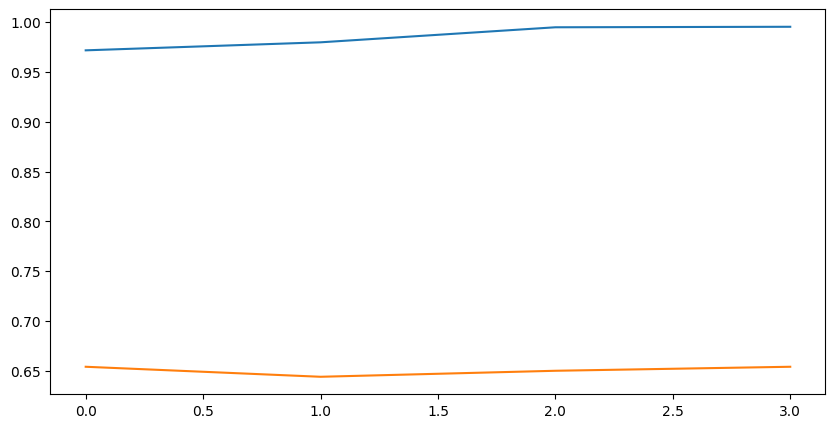

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize= (10,5))
plt.plot(history.history['accuracy'], label= 'Accuracy')
plt.plot(history.history['val_accuracy'], label= 'Validation Accuracy')

In [34]:
model.save('../data/ann_model.h5')

In [35]:
from tensorflow.keras.models import load_model

loaded_model = load_model('../data/ann_model.h5')
loaded_model.evaluate(X_test, y_test, verbose=0)

[1.2463499307632446, 0.653923511505127]